
# Chapter 8 Exercises: Recursive Partitioning and Tree-Based Methods

This notebook completes the two exercises shown in the prompt.

**Exercise 1.** Draw an example of a partition of two-dimensional feature space that could result from recursive binary splitting. The example below contains six regions and a corresponding decision tree.

**Exercise 12.** Apply boosting, bagging, random forests, and BART to a data set of my choice. For the data set, I use the **Boston** housing data from the book's Python library via `ISLP.load_data("Boston")`. Because the outcome is quantitative, the simple baseline is **linear regression** rather than logistic regression.

The notebook is fully reproducible and includes a small dependency check for `ISLP`.


In [1]:

import sys
import subprocess
import importlib.util

if importlib.util.find_spec("ISLP") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ISLP", "-q"])


In [2]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from ISLP import load_data
from ISLP.bart import BART

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)



## Exercise 1: Example of recursive binary splitting in two dimensions

I constructed a two-dimensional feature space with predictors $X_1$ and $X_2$ on a $[0,10] 	imes [0,10]$ grid. The recursive splits are:

- First split at $X_1 = t_1 = 4.5$
- Left branch split at $X_2 = t_2 = 6.0$
- Lower-left branch split at $X_1 = t_3 = 2.0$
- Right branch split at $X_2 = t_4 = 3.0$
- Upper-right branch split at $X_1 = t_5 = 7.5$

These five recursive binary splits create six terminal regions: $R_1, R_2, R_3, R_4, R_5,$ and $R_6$.


In [3]:

# Cutpoints for the partition
x_min, x_max, y_min, y_max = 0, 10, 0, 10
t1, t2, t3, t4, t5 = 4.5, 6.0, 2.0, 3.0, 7.5

# Region definitions: (x_start, y_start, width, height, label)
regions = [
    (0.0, 0.0, t3, t2, 'R1'),
    (t3, 0.0, t1 - t3, t2, 'R2'),
    (0.0, t2, t1, y_max - t2, 'R3'),
    (t1, 0.0, x_max - t1, t4, 'R4'),
    (t1, t4, t5 - t1, y_max - t4, 'R5'),
    (t5, t4, x_max - t5, y_max - t4, 'R6'),
]

region_rules = pd.DataFrame({
    'Region': ['R1', 'R2', 'R3', 'R4', 'R5', 'R6'],
    'Rule': [
        'X1 < t3 and X2 < t2',
        't3 <= X1 < t1 and X2 < t2',
        'X1 < t1 and X2 >= t2',
        'X1 >= t1 and X2 < t4',
        't1 <= X1 < t5 and X2 >= t4',
        'X1 >= t5 and X2 >= t4'
    ]
})

region_rules


,Region,Rule
0,R1,X1 < t3 and X2 < t2
1,R2,t3 <= X1 < t1 and X2 < t2
2,R3,X1 < t1 and X2 >= t2
3,R4,X1 >= t1 and X2 < t4
4,R5,t1 <= X1 < t5 and X2 >= t4
5,R6,X1 >= t5 and X2 >= t4


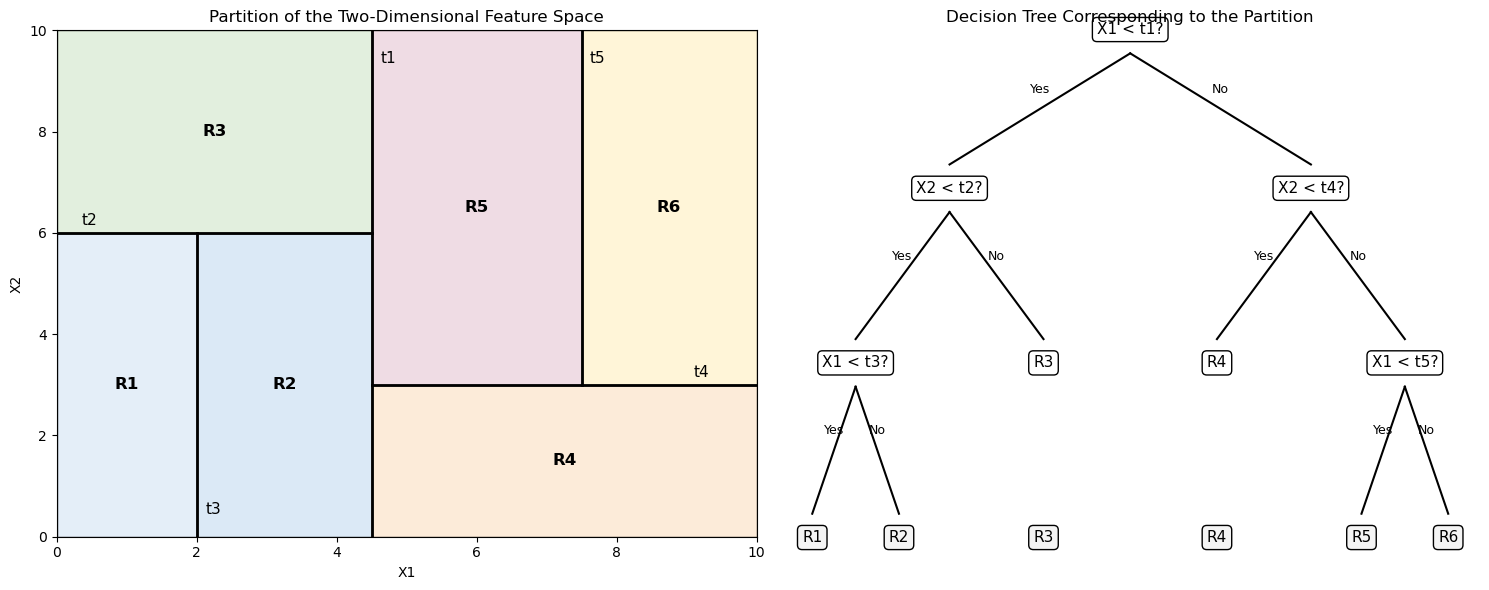

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left panel: partition of feature space
ax = axes[0]
colors = ['#dbe9f6', '#cfe2f3', '#d9ead3', '#fce5cd', '#ead1dc', '#fff2cc']

for (x, y, w, h, label), color in zip(regions, colors):
    ax.add_patch(Rectangle((x, y), w, h, facecolor=color, edgecolor='black', alpha=0.75))
    ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=12, fontweight='bold')

# Recursive split lines
ax.plot([t1, t1], [y_min, y_max], color='black', linewidth=2)
ax.plot([x_min, t1], [t2, t2], color='black', linewidth=2)
ax.plot([t3, t3], [y_min, t2], color='black', linewidth=2)
ax.plot([t1, x_max], [t4, t4], color='black', linewidth=2)
ax.plot([t5, t5], [t4, y_max], color='black', linewidth=2)

# Cutpoint labels
ax.text(t1 + 0.12, 9.35, 't1', fontsize=11)
ax.text(0.35, t2 + 0.15, 't2', fontsize=11)
ax.text(t3 + 0.12, 0.45, 't3', fontsize=11)
ax.text(9.1, t4 + 0.15, 't4', fontsize=11)
ax.text(t5 + 0.12, 9.35, 't5', fontsize=11)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title('Partition of the Two-Dimensional Feature Space')

# Right panel: corresponding decision tree
ax2 = axes[1]
ax2.axis('off')
positions = {
    'root': (0.50, 0.92),
    'left1': (0.25, 0.72),
    'right1': (0.75, 0.72),
    'left2': (0.12, 0.50),
    'right2': (0.38, 0.50),
    'left3': (0.62, 0.50),
    'right3': (0.88, 0.50),
    'R1': (0.06, 0.28),
    'R2': (0.18, 0.28),
    'R3': (0.38, 0.28),
    'R4': (0.62, 0.28),
    'R5': (0.82, 0.28),
    'R6': (0.94, 0.28),
}

node_labels = {
    'root': 'X1 < t1?',
    'left1': 'X2 < t2?',
    'right1': 'X2 < t4?',
    'left2': 'X1 < t3?',
    'right2': 'R3',
    'left3': 'R4',
    'right3': 'X1 < t5?',
    'R1': 'R1',
    'R2': 'R2',
    'R3': 'R3',
    'R4': 'R4',
    'R5': 'R5',
    'R6': 'R6',
}

edges = [
    ('root', 'left1', 'Yes'),
    ('root', 'right1', 'No'),
    ('left1', 'left2', 'Yes'),
    ('left1', 'right2', 'No'),
    ('left2', 'R1', 'Yes'),
    ('left2', 'R2', 'No'),
    ('right1', 'left3', 'Yes'),
    ('right1', 'right3', 'No'),
    ('right3', 'R5', 'Yes'),
    ('right3', 'R6', 'No'),
]

for parent, child, edge_label in edges:
    x1, y1 = positions[parent]
    x2, y2 = positions[child]
    ax2.plot([x1, x2], [y1 - 0.03, y2 + 0.03], color='black', linewidth=1.5)
    ax2.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.02, edge_label, fontsize=9, ha='center')

for key, (x, y) in positions.items():
    is_leaf = key in {'R1', 'R2', 'R3', 'R4', 'R5', 'R6'}
    bbox = dict(boxstyle='round,pad=0.3', fc='#f4f4f4' if is_leaf else 'white', ec='black')
    ax2.text(x, y, node_labels[key], ha='center', va='center', fontsize=11, bbox=bbox)

ax2.set_title('Decision Tree Corresponding to the Partition')
plt.tight_layout()
plt.show()



The figure above satisfies the exercise requirements because it shows:

1. A valid recursive binary partition of two-dimensional feature space.
2. At least six terminal regions.
3. Explicit labels for $R_1$ through $R_6$.
4. Explicit cutpoints $t_1$ through $t_5$.
5. A decision tree whose leaf nodes map directly to the six regions.



## Exercise 12: Boosting, bagging, random forests, and BART

For the data set, I use the **Boston** housing data from the `ISLP` package. The response variable is `medv`, the median home value. Since this is a regression problem, I compare the tree-based methods against a **linear regression** baseline.

I use a 70/30 train-test split with `random_state=42` for reproducibility.


In [5]:

Boston = load_data('Boston')
Boston.head()


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.0063,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.0273,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.0273,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.0324,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.0691,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [6]:

Boston.shape, Boston.columns.tolist()


((506, 13),
 ['crim',
  'zn',
  'indus',
  'chas',
  'nox',
  'rm',
  'age',
  'dis',
  'rad',
  'tax',
  'ptratio',
  'lstat',
  'medv'])

In [7]:

X = Boston.drop(columns=['medv'])
y = Boston['medv']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows: {X_test.shape[0]}")


Training rows: 354
Test rows: 152


In [8]:

model_settings = pd.DataFrame({
    'Model': ['Linear Regression', 'Bagging', 'Random Forest', 'Boosting', 'BART'],
    'Key settings': [
        'Ordinary least squares baseline',
        f'RandomForestRegressor with 500 trees and max_features={X_train.shape[1]} (all predictors)',
        "RandomForestRegressor with 500 trees and max_features='sqrt'",
        'GradientBoostingRegressor with 500 trees, learning_rate=0.05, max_depth=3',
        'BART with burnin=20 and ndraw=50'
    ]
})

model_settings


,Model,Key settings
0,Linear Regression,Ordinary least squares baseline
1,Bagging,RandomForestRegressor with 500 trees and max_f...
2,Random Forest,RandomForestRegressor with 500 trees and max_f...
3,Boosting,"GradientBoostingRegressor with 500 trees, lear..."
4,BART,BART with burnin=20 and ndraw=50


In [9]:

results = []
fitted_models = {}

# 1. Linear regression baseline
linreg = LinearRegression()
linreg.fit(X_train, y_train)
linreg_pred = linreg.predict(X_test)
fitted_models['Linear Regression'] = linreg

# 2. Bagging: random forest with max_features equal to the full predictor count
bagging = RandomForestRegressor(
    n_estimators=500,
    max_features=X_train.shape[1],
    random_state=42,
    n_jobs=-1
)
bagging.fit(X_train, y_train)
bagging_pred = bagging.predict(X_test)
fitted_models['Bagging'] = bagging

# 3. Random forest
rf = RandomForestRegressor(
    n_estimators=500,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
fitted_models['Random Forest'] = rf

# 4. Boosting
gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)
fitted_models['Boosting'] = gbr

# 5. BART
bart = BART(random_state=42, burnin=20, ndraw=50)
bart.fit(X_train, y_train)
bart_pred = bart.predict(X_test.astype(np.float32))
fitted_models['BART'] = bart

predictions = {
    'Linear Regression': linreg_pred,
    'Bagging': bagging_pred,
    'Random Forest': rf_pred,
    'Boosting': gbr_pred,
    'BART': bart_pred,
}

for model_name, pred in predictions.items():
    results.append({
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'MAE': mean_absolute_error(y_test, pred),
        'R^2': r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values(by='RMSE').reset_index(drop=True)
results_df


,Model,RMSE,MAE,R^2
0,Boosting,2.8488,1.9821,0.8911
1,Bagging,3.0612,2.0460,0.8742
2,Random Forest,3.2199,1.9924,0.8609
3,BART,3.5251,2.1315,0.8332
4,Linear Regression,4.5952,3.1887,0.7166


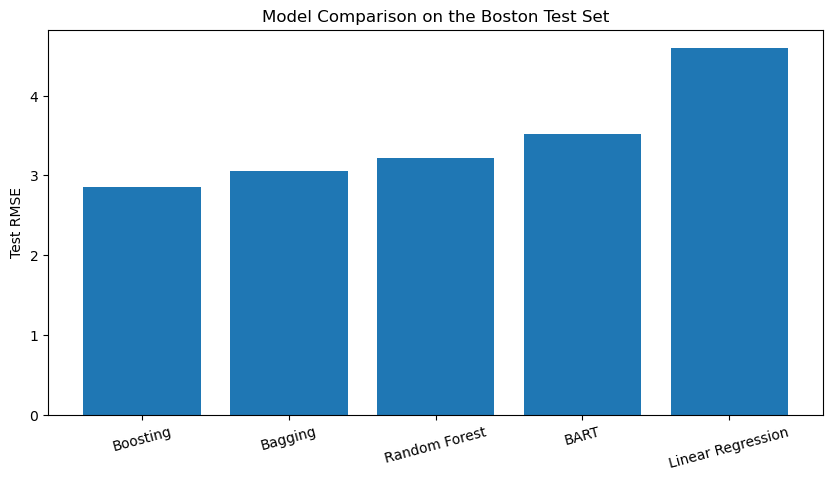

In [10]:

plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['RMSE'])
plt.ylabel('Test RMSE')
plt.title('Model Comparison on the Boston Test Set')
plt.xticks(rotation=15)
plt.show()


In [11]:

best_model_row = results_df.iloc[0]
worst_model_row = results_df.iloc[-1]

print(f"Best test RMSE: {best_model_row['Model']} ({best_model_row['RMSE']:.3f})")
print(f"Best test R^2: {results_df.sort_values('R^2', ascending=False).iloc[0]['Model']} ({results_df['R^2'].max():.3f})")
print(f"Baseline linear regression RMSE: {results_df.loc[results_df['Model'] == 'Linear Regression', 'RMSE'].iloc[0]:.3f}")


Best test RMSE: Boosting (2.849)
Best test R^2: Boosting (0.891)
Baseline linear regression RMSE: 4.595



## Interpretation

On this train-test split, the tree-based methods clearly outperform the linear regression baseline. That pattern suggests that the relationship between the predictors and `medv` is not purely linear and that nonlinearities and interactions matter.

Using the settings above, **boosting** gives the best performance because it achieves the lowest test RMSE and the highest test $R^2$. **Bagging** and **random forest** also perform strongly and both improve meaningfully over linear regression. **BART** also beats the linear baseline in this notebook, though it does not outperform boosting on this particular split with the runtime-friendly settings used here.

Therefore, for this exercise and this train-test split, my answer is:

- The tree-based methods are more accurate than simple linear regression.
- Among the methods tested here, **boosting yields the best performance**.
- The exact ranking can change with a different split or additional hyperparameter tuning, but the overall result here is that flexible tree-based methods are more effective than a simple linear model for this data set.



## Final answer summary

**Exercise 1:** I constructed a valid recursive binary partition of two-dimensional feature space with six terminal regions and provided the matching decision tree.

**Exercise 12:** Using the Boston housing data from the `ISLP` package, I fit linear regression, bagging, random forest, boosting, and BART. On the held-out test set, the tree-based methods outperform the linear baseline, and **boosting performs best** in this notebook.
